# Comparative Study of Clustering Methods

## Objective

This notebook investigates three commonly used **unsupervised clustering** methods:

1. **k-Means**: centroid-based clustering
2. **Agglomerative hierarchical clustering**: a tree-based approach
3. **DBSCAN**: density-based clustering

The goal is to understand why different algorithms produce different results, how their parameters affect the result, and how their performance can be evaluated.

### Questions this notebook addresses

- How does feature scaling affect distance-based clustering?
- How should the number of clusters or density parameters be selected?
- When do internal metrics such as Silhouette and Davies-Bouldin give useful information?
- How do external metrics such as ARI and NMI behave when ground-truth labels are available?
- Why can an algorithm that performs well on one dataset fail on another?
- In particular, what happens when clusters are **non-convex** or when noise is present?

> **Note:** clustering is unsupervised. The true class labels are deliberately not supplied to the clustering algorithms. For Iris, those labels are retained separately and are used only afterward for external evaluation.

## Experimental design

The notebook uses three datasets with complementary purposes.

| Dataset | Role in the experiment | Known labels? | Geometry |
|---|---|---:|---|
| Iris | Main comparison between the three algorithms | Yes, held out | Relatively compact, partly overlapping groups |
| Moons | Stress test for cluster shape assumptions | Yes | Two interleaving, non-convex clusters |
| Circles | Stress test for cluster shape assumptions | Yes | Nested, non-convex clusters |

The same scaling convention is used throughout the experiments so that Euclidean-distance-based methods are not dominated by features with larger numerical units.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

In [2]:
# load iris, drop labels
iris = load_iris()
X_iris_raw = iris.data        # features only
y_iris_true = iris.target     # hidden ground truth, for external eval
feature_names = iris.feature_names

print("iris dataset loaded.")
print(f"    shape: {X_iris_raw.shape}")
print(f"    features: {feature_names}")
print(f"    true classes (hidden): {np.unique(y_iris_true)} -> {iris.target_names}")
print(f"    class distribution: {np.bincount(y_iris_true)}")

iris dataset loaded.
    shape: (150, 4)
    features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
    true classes (hidden): [0 1 2] -> ['setosa' 'versicolor' 'virginica']
    class distribution: [50 50 50]


## Data preparation: Iris

The **Iris dataset** contains 150 observations described by four measurements:

- sepal length
- sepal width
- petal length
- petal width

There are three known species/classes with 50 samples each.

For the clustering task, `X_iris_raw` is the only input. `y_iris_true` is kept aside as **hidden ground truth**. This gives us an unusual but useful experimental setup: we can imitate an unsupervised problem while still being able to measure how closely the discovered partition agrees with the known classes afterward.

## Synthetic datasets

`make_moons` contains two interleaving curved groups, while `make_circles` contains one circle inside another. Both are examples where a simple "nearest centroid" view of a cluster is a poor fit.

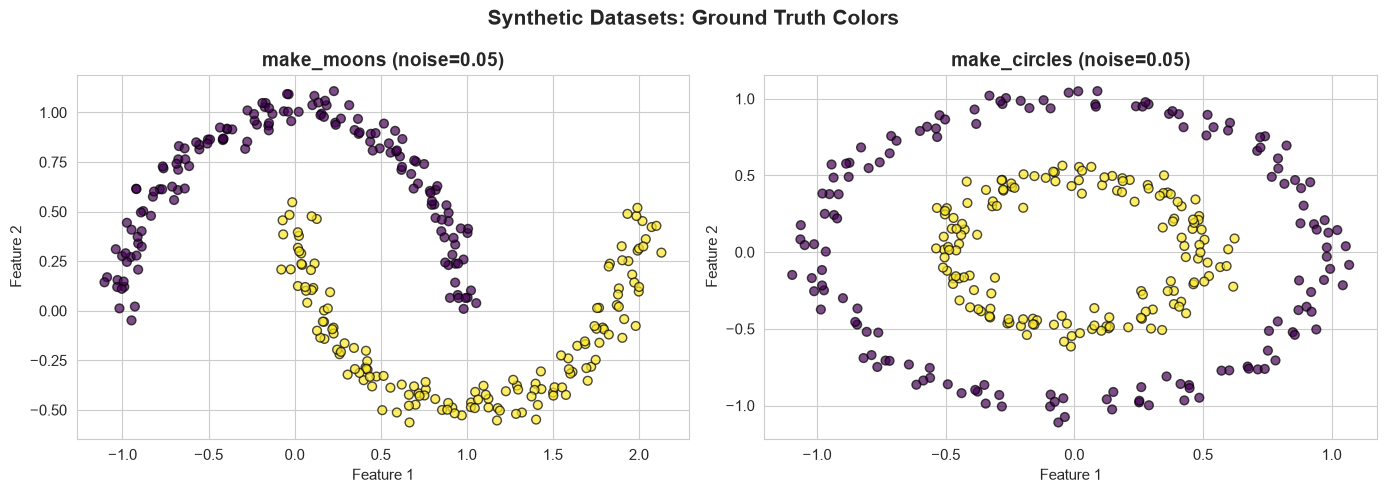

In [3]:
# generate synthetic datasets
N_SYNTHETIC = 300

# Moons: two interleaving half-circles
X_moons_raw, y_moons = make_moons(
    n_samples=N_SYNTHETIC, noise=0.05, random_state=RANDOM_STATE
)

# Circles: a larger circle with a smaller circle inside
X_circles_raw, y_circles = make_circles(
    n_samples=N_SYNTHETIC, noise=0.05, factor=0.5, random_state=RANDOM_STATE
)

# Visualize raw synthetic data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_moons_raw[:, 0], X_moons_raw[:, 1], c=y_moons, 
                cmap='viridis', s=40, edgecolors='k', alpha=0.7)
axes[0].set_title('make_moons (noise=0.05)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

axes[1].scatter(X_circles_raw[:, 0], X_circles_raw[:, 1], c=y_circles, 
                cmap='viridis', s=40, edgecolors='k', alpha=0.7)
axes[1].set_title('make_circles (noise=0.05)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.suptitle('Synthetic Datasets: Ground Truth Colors', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# apply StandardScaler to all datasets
scaler_iris = StandardScaler()
X_iris = scaler_iris.fit_transform(X_iris_raw)

scaler_moons = StandardScaler()
X_moons = scaler_moons.fit_transform(X_moons_raw)

scaler_circles = StandardScaler()
X_circles = scaler_circles.fit_transform(X_circles_raw)

# Verify scaling
print("=== Iris: After StandardScaler ===")
print(f"  Mean per feature: {np.round(X_iris.mean(axis=0), 6)}")
print(f"  Std  per feature: {np.round(X_iris.std(axis=0), 6)}")

print("\n=== Moons: After StandardScaler ===")
print(f"  Mean: {np.round(X_moons.mean(axis=0), 6)}")
print(f"  Std:  {np.round(X_moons.std(axis=0), 6)}")

print("\n=== Circles: After StandardScaler ===")
print(f"  Mean: {np.round(X_circles.mean(axis=0), 6)}")
print(f"  Std:  {np.round(X_circles.std(axis=0), 6)}")

=== Iris: After StandardScaler ===
  Mean per feature: [-0. -0. -0. -0.]
  Std  per feature: [1. 1. 1. 1.]

=== Moons: After StandardScaler ===
  Mean: [-0. -0.]
  Std:  [1. 1.]

=== Circles: After StandardScaler ===
  Mean: [-0.  0.]
  Std:  [1. 1.]


In [5]:
# Quick dataset overview
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Iris:    {X_iris_raw.shape[0]} samples, {X_iris_raw.shape[1]} features")
print(f"Moons:   {X_moons_raw.shape[0]} samples, {X_moons_raw.shape[1]} features")
print(f"Circles: {X_circles_raw.shape[0]} samples, {X_circles_raw.shape[1]} features")
print()
print("Algorithms compared: K-Means, Agglomerative (Ward), DBSCAN")
print("All clustering is performed without using the ground-truth labels.")

DATASET OVERVIEW
Iris:    150 samples, 4 features
Moons:   300 samples, 2 features
Circles: 300 samples, 2 features

Algorithms compared: K-Means, Agglomerative (Ward), DBSCAN
All clustering is performed without using the ground-truth labels.


## A note on feature scaling

Most of the methods in this notebook rely on distances. If one feature has a much larger numerical scale than another, it can dominate those distances.

`StandardScaler` transforms features such that each feature has mean 0 and standard deviation 1 in the fitted dataset.

This does **not** mean scaling is universally required for every clustering problem. It is a modeling choice that should be justified by the meaning and units of the features. Here it provides a fair common basis for comparing the distance-based methods.

## Visual inspection of the scaled Iris data

Iris has four dimensions, so a direct scatter plot cannot show the full geometry. We can use **PCA (Principal Component Analysis)** purely as a visualization aid.

PCA finds directions of greatest variance and projects the data into two dimensions. This projection is **not** used to fit the clustering models below; clustering continues to use all four scaled features.

A 2-D visualization can therefore help us inspect the data, but it should not be interpreted as a complete representation of the original feature space.

Explained variance by the first two principal components:
  PC1: 0.730
  PC2: 0.229
  Total: 0.958


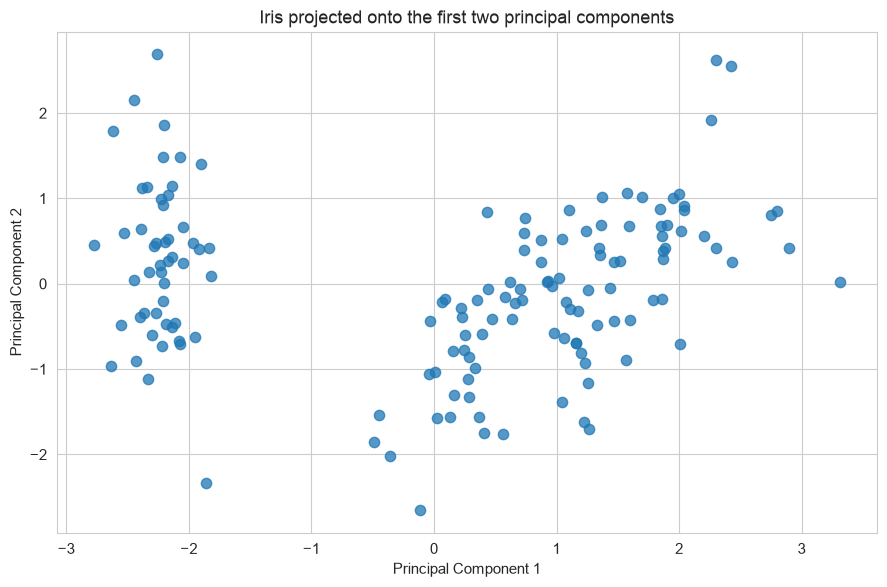

In [6]:
# PCA is used only for visualization, not for fitting the clustering models.
pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris)

print("Explained variance by the first two principal components:")
print(f"  PC1: {pca_iris.explained_variance_ratio_[0]:.3f}")
print(f"  PC2: {pca_iris.explained_variance_ratio_[1]:.3f}")
print(f"  Total: {pca_iris.explained_variance_ratio_.sum():.3f}")

plt.figure(figsize=(9, 6))
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], s=55, alpha=0.75)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris projected onto the first two principal components")
plt.tight_layout()
plt.show()

## Algorithm 1: k-Means Clustering

k-Means partitions the data into a user-specified number $k$ of clusters by repeatedly alternating between **assignment** and **centroid update**.

1. Initialize $k$ centroids.
2. Assign each point to the nearest centroid using Euclidean distance.
3. Replace each centroid with the mean of the points assigned to it.
4. Repeat until the assignments/centroids stabilize or the iteration limit is reached.

The objective minimized by k-Means is the within-cluster sum of squared distances:

$$
\mathrm{WCSS}
= \sum_{j=1}^{k}\sum_{x_i \in C_j}\|x_i-\mu_j\|^2
$$

In scikit-learn this is reported as **inertia**.

### Choosing $k$

Because $k$ must be supplied in advance, we inspect two diagnostics:

- **Elbow / inertia:** inertia always decreases (or stays the same) as $k$ grows, so the useful signal is where the decrease starts becoming much smaller.
- **Silhouette score:** compares how close points are to their own cluster versus the nearest alternative cluster. Higher values are generally better.

Neither diagnostic should be treated as an automatic "correct answer". Domain knowledge and the geometry of the data still matter.

k-Means works best when clusters are reasonably compact and convex in the chosen feature space. It is also sensitive to feature scaling and to the choice of $k$.

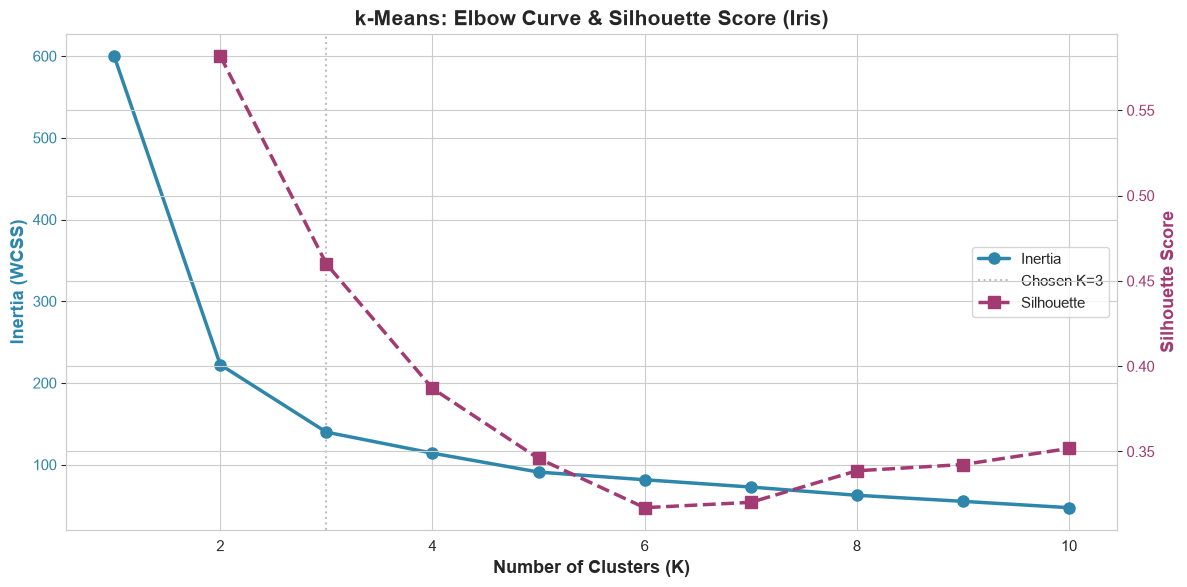


K | Inertia    | Silhouette
--|------------|-----------
 1 |     600.00 |   N/A 
 2 |     222.36 | 0.5818
 3 |     139.82 | 0.4599
 4 |     114.09 | 0.3869
 5 |      90.93 | 0.3459
 6 |      81.54 | 0.3171
 7 |      72.63 | 0.3202
 8 |      62.54 | 0.3387
 9 |      55.12 | 0.3424
10 |      47.39 | 0.3518


In [7]:
K_range = range(1, 11)
inertias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, 
                    random_state=RANDOM_STATE)
    kmeans.fit(X_iris)
    inertias.append(kmeans.inertia_)
    
    # Silhouette requires at least 2 clusters
    if k >= 2:
        sil = silhouette_score(X_iris, kmeans.labels_)
        silhouettes.append(sil)
    else:
        silhouettes.append(np.nan)

# Dual y-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#2E86AB'
ax1.set_xlabel('Number of Clusters (K)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', color=color1, fontsize=13, fontweight='bold')
ax1.plot(K_range, inertias, 'o-', color=color1, linewidth=2.5, markersize=8, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.axvline(x=3, color='gray', linestyle=':', alpha=0.5, label='Chosen K=3')

# Twin axis for silhouette
ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.set_ylabel('Silhouette Score', color=color2, fontsize=13, fontweight='bold')
ax2.plot(list(K_range), silhouettes, 's--', color=color2, linewidth=2.5, markersize=8, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('k-Means: Elbow Curve & Silhouette Score (Iris)', fontsize=15, fontweight='bold')
fig.tight_layout()

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=11)

plt.show()

# Print values
print("\nK | Inertia    | Silhouette")
print("--|------------|-----------")
for k, inert, sil in zip(K_range, inertias, silhouettes):
    sil_str = f"{sil:.4f}" if not np.isnan(sil) else "  N/A "
    print(f"{k:2d} | {inert:10.2f} | {sil_str}")

In [8]:
# choose k=3
K_CHOSEN = 3

t0 = time.perf_counter()
kmeans_final = KMeans(n_clusters=K_CHOSEN, init='k-means++', n_init=10, 
                       random_state=RANDOM_STATE)
kmeans_labels = kmeans_final.fit_predict(X_iris)
t1 = time.perf_counter()
kmeans_time = t1 - t0

print(f"k-Means fitted in {kmeans_time:.6f} seconds")
print(f"   k = {K_CHOSEN}")
print(f"   cluster sizes: {np.bincount(kmeans_labels)}")
print(f"   final inertia: {kmeans_final.inertia_:.2f}")

k-Means fitted in 0.005996 seconds
   k = 3
   cluster sizes: [53 50 47]
   final inertia: 139.82


### Interpreting the k-Means result

The selected \(k=3\) is a **model choice**, not something k-Means discovered by itself. The elbow/silhouette diagnostics provide evidence for the choice, while the final labels show how the observations were partitioned.

The cluster labels themselves have no semantic ordering: cluster `0` is not inherently "class 0". What matters is the partition of the observations.

## Algorithm 2: Agglomerative Hierarchical Clustering

Agglomerative hierarchical clustering starts with **one cluster per observation** and repeatedly merges the closest pair of clusters until everything belongs to one cluster.

The sequence of merges is represented by a **dendrogram**. Unlike k-Means, the dendrogram lets us inspect the hierarchy before deciding where to cut it.

This notebook uses **Ward linkage**. At each merge, Ward's method chooses the pair that results in the smallest increase in total within-cluster variance. This tends to favor compact clusters.

The dendrogram gives us two related ways to think about the final clustering:

- choose a horizontal cut height and let the number of resulting groups emerge;
- specify the desired number of clusters directly.

Here we use the dendrogram to motivate a three-cluster solution and then fit the corresponding scikit-learn model.

Ward linkage is especially suited to compact, roughly spherical groups under a Euclidean geometry. Other linkage rules (single, complete, average, etc.) can produce substantially different structures.

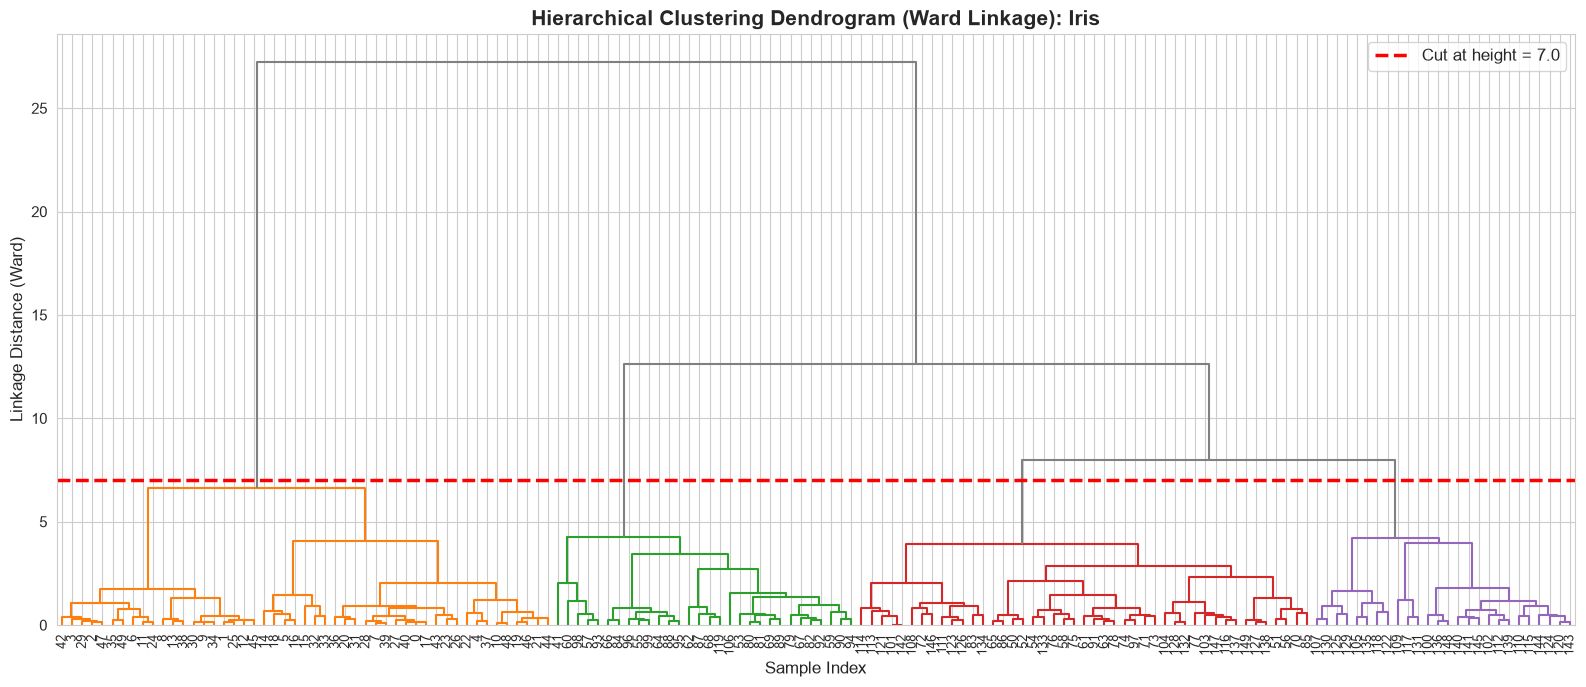


Cutting the dendrogram at height = 7.0 yields 4 clusters.
   Cluster sizes: [ 0 49 30 45 26]


In [9]:
# compute linkage matrix using Ward's method
Z = linkage(X_iris, method='ward')

fig, ax = plt.subplots(figsize=(16, 7))
dn = dendrogram(Z, ax=ax, color_threshold=7.0, 
                above_threshold_color='gray', leaf_font_size=9)

# Draw horizontal threshold line
CUT_HEIGHT = 7.0
ax.axhline(y=CUT_HEIGHT, color='red', linestyle='--', linewidth=2.5, 
           label=f'Cut at height = {CUT_HEIGHT}')

ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage): Iris', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Linkage Distance (Ward)', fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Determine number of clusters at the cut height
n_clusters_hier = fcluster(Z, t=CUT_HEIGHT, criterion='distance')
n_hier = len(np.unique(n_clusters_hier))
print(f"\nCutting the dendrogram at height = {CUT_HEIGHT} yields {n_hier} clusters.")
print(f"   Cluster sizes: {np.bincount(n_clusters_hier)}")

In [10]:
# fit final agglomerative clustering
HIER_K = 3

t0 = time.perf_counter()
hier_final = AgglomerativeClustering(n_clusters=HIER_K, linkage='ward')
hier_labels = hier_final.fit_predict(X_iris)
t1 = time.perf_counter()
hier_time = t1 - t0

print(f"Hierarchical Clustering fitted in {hier_time:.6f} seconds")
print(f"   n_clusters = {HIER_K}")
print(f"   Cluster sizes: {np.bincount(hier_labels)}")

Hierarchical Clustering fitted in 0.001121 seconds
   n_clusters = 3
   Cluster sizes: [71 49 30]


### Interpreting the hierarchical result

The dendrogram and the final three-cluster solution provide two complementary views: the dendrogram shows **how** groups are related, while the final labels provide a flat partition that can be compared directly with the other algorithms.

## Algorithm 3: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN defines clusters in terms of local density rather than centroids. It can therefore recover shapes that are difficult for k-Means.

Its two main parameters are:

- `eps` ($\epsilon$): radius of the neighborhood around each point.
- `min_samples`: minimum number of points in an $\epsilon$-neighborhood for a point to be considered a **core point**.

Points are then interpreted as:

- **Core:** sufficiently many neighbors within $\epsilon$.
- **Border:** not dense enough to be core, but reachable from a core point.
- **Noise:** not density-connected to a cluster, assigned label `-1`.

### Choosing `eps`

A common heuristic is a **k-distance graph**: calculate each point's distance to its \(k\)-th nearest neighbor and sort those distances. A noticeable bend ("knee") can indicate a useful transition between dense neighborhoods and sparse regions.

The knee is a heuristic, not a theorem. In practice, `eps` should be checked against the resulting number of clusters and amount of noise.

An advantages is that DBSCAN does not require the number of clusters beforehand and can identify noise.

However, a single density threshold can struggle when different real clusters have very different densities.

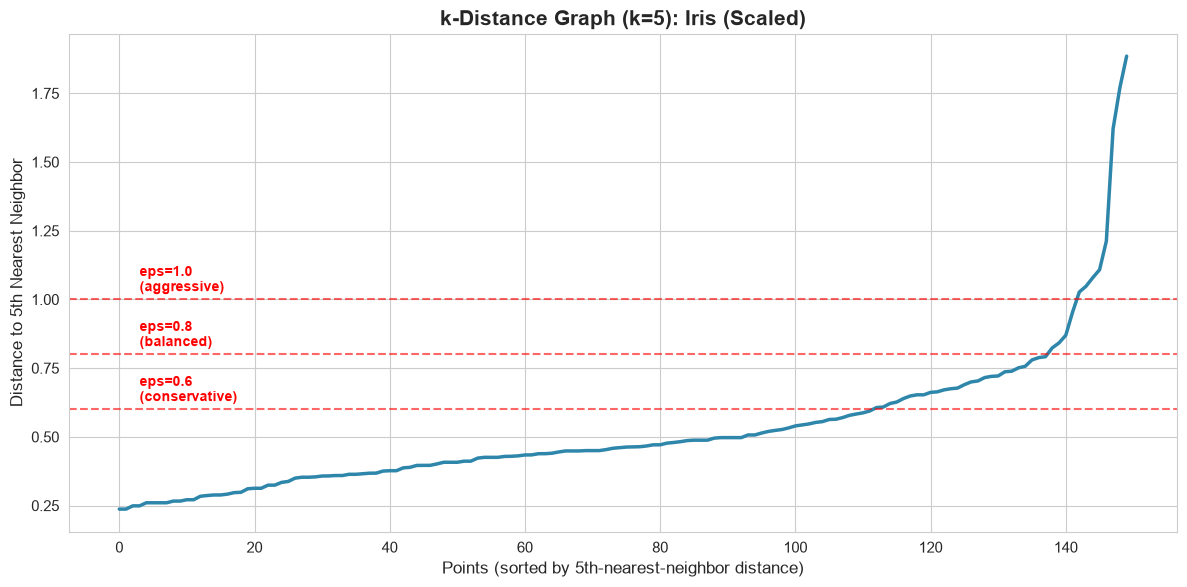

In [11]:
# k-distance graph (5th nearest neighbor)
MIN_SAMPLES = 5

# Compute distances to the k nearest neighbors (includes the point itself at index 0)
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_iris)
distances, indices = nn.kneighbors(X_iris)

# The kth-nearest-neighbor distance; the final returned neighbor is used
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(k_distances, linewidth=2.5, color='#2E86AB')
ax.set_xlabel('Points (sorted by 5th-nearest-neighbor distance)', fontsize=12)
ax.set_ylabel(f'Distance to {MIN_SAMPLES}th Nearest Neighbor', fontsize=12)
ax.set_title(f'k-Distance Graph (k={MIN_SAMPLES}): Iris (Scaled)', 
             fontsize=15, fontweight='bold')

# Annotate candidate eps values
for eps_candidate, label in [(0.6, 'eps=0.6\n(conservative)'), 
                              (0.8, 'eps=0.8\n(balanced)'), 
                              (1.0, 'eps=1.0\n(aggressive)')]:
    ax.axhline(y=eps_candidate, color='red', linestyle='--', alpha=0.6)
    ax.annotate(label, xy=(len(k_distances)*0.02, eps_candidate + 0.03), 
                fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

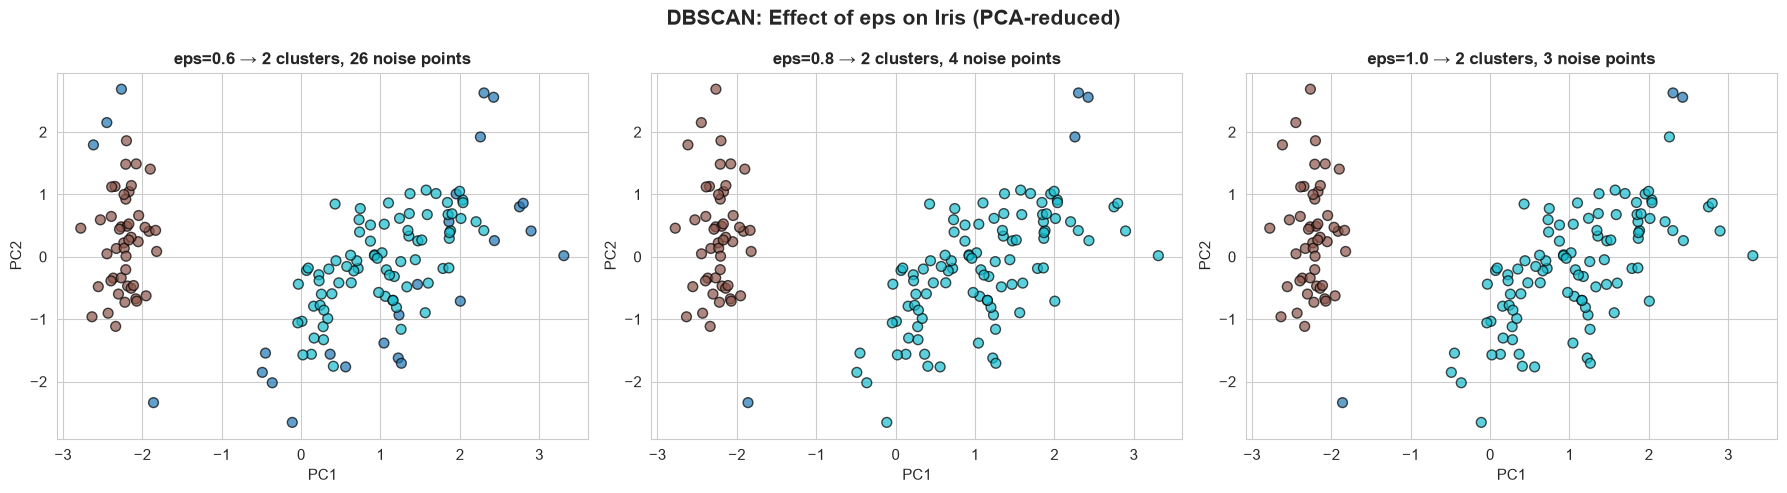

   eps | Clusters | Noise Points
----------------------------------------------------------------------
   0.6 |        2 |           26
   0.8 |        2 |            4
   1.0 |        2 |            3


In [12]:
# DBSCAN: try 3 different values for eps
eps_values = [0.6, 0.8, 1.0]
dbscan_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = dbscan.fit_predict(X_iris)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    dbscan_results[eps] = {
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise
    }
    
    # PCA for visualization
    pca = PCA(n_components=2)
    X_iris_pca = pca.fit_transform(X_iris)
    
    axes[i].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels, 
                    cmap='tab10', s=50, edgecolors='k', alpha=0.7)
    axes[i].set_title(f'eps={eps} → {n_clusters} clusters, {n_noise} noise points', 
                       fontsize=12, fontweight='bold')
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')

plt.suptitle('DBSCAN: Effect of eps on Iris (PCA-reduced)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"{'eps':>6} | {'Clusters':>8} | {'Noise Points':>12}")
print("-" * 70)
for eps in eps_values:
    r = dbscan_results[eps]
    print(f"{eps:6.1f} | {r['n_clusters']:8d} | {r['n_noise']:12d}")

### What the DBSCAN sweep is telling us

The small sweep above is more informative than simply reporting one `eps` value. In DBSCAN, changing `eps` changes the definition of "dense enough" and can cause clusters to merge or points to become noise.

For a real project, this kind of parameter sensitivity analysis is often more defensible than choosing a value solely because it gives a desired number of clusters.

In [13]:
# choose eps = 0.8 as the final value
EPS_CHOSEN = 0.8

# fit final DBSCAN
t0 = time.perf_counter()
dbscan_final = DBSCAN(eps=EPS_CHOSEN, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan_final.fit_predict(X_iris)
t1 = time.perf_counter()
dbscan_time = t1 - t0

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"DBSCAN fitted in {dbscan_time:.6f} seconds")
print(f"   eps = {EPS_CHOSEN}, min_samples = {MIN_SAMPLES}")
print(f"   Clusters found: {n_clusters_dbscan}")
print(f"   Noise points detected: {n_noise_dbscan}")
print(f"   Cluster label distribution: {np.bincount(dbscan_labels + 1)}")
print(f"     (label 0 in this count = noise points with label -1)")

DBSCAN fitted in 0.001752 seconds
   eps = 0.8, min_samples = 5
   Clusters found: 2
   Noise points detected: 4
   Cluster label distribution: [ 4 49 97]
     (label 0 in this count = noise points with label -1)


### Interpreting the DBSCAN result

The value `eps=0.8` is selected from a small parameter sweep informed by the k-distance graph. This is intentionally not presented as a universal rule: changing `eps` changes both the number of clusters and the number of points labeled as noise.

In other applications, it is often useful to examine a broader parameter grid or use domain knowledge about meaningful neighborhood distances.

## 6. Evaluation Metrics

Clustering evaluation is easiest to understand when we separate **internal** and **external** validation.

### Internal metrics: no ground truth required

**Silhouette score**

$$
s = \frac{b-a}{\max(a,b)}
$$

where $a$ is the average distance from a point to its own cluster and $b$ is the lowest average distance to another cluster. Values closer to 1 indicate better separation; values around 0 indicate substantial overlap; negative values can indicate poor assignments.

**Davies-Bouldin index**

This measures how similar each cluster is to its most similar competing cluster. Lower values indicate better separation/compactness.

These metrics are useful when labels do not exist, but they encode assumptions about what a "good" cluster looks like.

### External metrics: ground truth available

Here the Iris labels are held out until evaluation.

- **Adjusted Rand Index (ARI):** compares pairwise agreement between two partitions while correcting for chance.
- **Normalized Mutual Information (NMI):** measures the amount of shared information between the predicted and true partitions.

Higher is better for both. A perfect partition receives ARI = 1 and NMI = 1.

### DBSCAN caveat

DBSCAN may label observations as noise (`-1`). For the internal metrics, this notebook excludes noise points so that the compactness/separation calculations are performed only on identified clusters.

That choice is useful but also important to remember: **the resulting internal score does not reward or penalize DBSCAN for how much data it discarded as noise**. The noise count is therefore reported separately.

For external metrics, the `-1` label remains part of the predicted partition, so noise assignments affect ARI/NMI.

In [14]:
# internal metrics (no labels)
def compute_internal_metrics(X, labels, algorithm_name):
    """
    Compute Silhouette Score and Davies-Bouldin Index.
    For DBSCAN, filter out noise points (label == -1).
    """
    labels = np.array(labels)
    
    # Check if this is DBSCAN (has noise)
    has_noise = -1 in labels
    
    if has_noise:
        non_noise_mask = labels != -1
        X_filtered = X[non_noise_mask]
        labels_filtered = labels[non_noise_mask]
        n_noise = np.sum(~non_noise_mask)
        n_clusters = len(set(labels_filtered))
        
        print(f"\n{'='*50}")
        print(f"  {algorithm_name}: Noise Filtering Applied")
        print(f"{'='*50}")
        print(f"  Total points: {len(labels)}")
        print(f"  Noise points removed: {n_noise}")
        print(f"  Points used for metrics: {len(labels_filtered)}")
        print(f"  Clusters (excluding noise): {n_clusters}")
        
        if n_clusters < 2:
            print(f"Fewer than 2 clusters, cannot compute metrics.")
            return None, None, n_noise
    else:
        X_filtered = X
        labels_filtered = labels
        n_noise = 0
        n_clusters = len(set(labels))
    
    sil = silhouette_score(X_filtered, labels_filtered)
    db = davies_bouldin_score(X_filtered, labels_filtered)
    
    print(f"  Silhouette Score:    {sil:.4f}  (higher is better, range [-1, 1])")
    print(f"  Davies-Bouldin Index: {db:.4f}  (lower is better, range [0, ∞))")
    
    return sil, db, n_noise

# --- K-Means ---
print("=" * 55)
print("  K-MEANS: Internal Metrics")
print("=" * 55)
kmeans_sil, kmeans_db, kmeans_noise = compute_internal_metrics(
    X_iris, kmeans_labels, "K-Means"
)

# --- Hierarchical ---
print("\n" + "=" * 55)
print("  HIERARCHICAL (Ward): Internal Metrics")
print("=" * 55)
hier_sil, hier_db, hier_noise = compute_internal_metrics(
    X_iris, hier_labels, "Hierarchical"
)

# --- DBSCAN ---
dbscan_sil, dbscan_db, dbscan_noise = compute_internal_metrics(
    X_iris, dbscan_labels, "DBSCAN"
)

  K-MEANS: Internal Metrics
  Silhouette Score:    0.4599  (higher is better, range [-1, 1])
  Davies-Bouldin Index: 0.8336  (lower is better, range [0, ∞))

  HIERARCHICAL (Ward): Internal Metrics
  Silhouette Score:    0.4467  (higher is better, range [-1, 1])
  Davies-Bouldin Index: 0.8035  (lower is better, range [0, ∞))

  DBSCAN: Noise Filtering Applied
  Total points: 150
  Noise points removed: 4
  Points used for metrics: 146
  Clusters (excluding noise): 2
  Silhouette Score:    0.5979  (higher is better, range [-1, 1])
  Davies-Bouldin Index: 0.5688  (lower is better, range [0, ∞))


In [15]:
# external metrics, using hidden ground truth
print("=" * 55)
print("  EXTERNAL METRICS vs. Hidden Ground Truth (Iris)")
print("=" * 55)
print(f"  Hidden labels: {np.unique(y_iris_true)}")
print(f"  Distribution:  {np.bincount(y_iris_true)}")
print()

# K-Means
kmeans_ari = adjusted_rand_score(y_iris_true, kmeans_labels)
kmeans_nmi = normalized_mutual_info_score(y_iris_true, kmeans_labels)
print(f"  K-Means:")
print(f"    ARI = {kmeans_ari:.4f}  (1.0 = perfect match)")
print(f"    NMI = {kmeans_nmi:.4f}  (1.0 = perfect match)")

# Hierarchical
hier_ari = adjusted_rand_score(y_iris_true, hier_labels)
hier_nmi = normalized_mutual_info_score(y_iris_true, hier_labels)
print(f"\n  Hierarchical (Ward):")
print(f"    ARI = {hier_ari:.4f}")
print(f"    NMI = {hier_nmi:.4f}")

# DBSCAN note: noise points are labeled -1, which counts as a "wrong" cluster
dbscan_ari = adjusted_rand_score(y_iris_true, dbscan_labels)
dbscan_nmi = normalized_mutual_info_score(y_iris_true, dbscan_labels)
print(f"\n  DBSCAN:")
print(f"    ARI = {dbscan_ari:.4f}")
print(f"    NMI = {dbscan_nmi:.4f}")
print(f"    Note: {dbscan_noise} noise points are treated as a separate")
print(f"    'cluster' by external metrics, which lowers the score.")

  EXTERNAL METRICS vs. Hidden Ground Truth (Iris)
  Hidden labels: [0 1 2]
  Distribution:  [50 50 50]

  K-Means:
    ARI = 0.6201  (1.0 = perfect match)
    NMI = 0.6595  (1.0 = perfect match)

  Hierarchical (Ward):
    ARI = 0.6153
    NMI = 0.6755

  DBSCAN:
    ARI = 0.5518
    NMI = 0.6900
    Note: 4 noise points are treated as a separate
    'cluster' by external metrics, which lowers the score.


### Looking beyond a single metric

ARI and NMI compress the agreement between two partitions into single numbers. A simple contingency table can show **which true classes tend to be grouped together** by each algorithm.

Remember that cluster IDs are arbitrary, so a table should be read by patterns of concentration rather than by matching numeric labels directly.

In [16]:
# Contingency tables: rows = true Iris classes, columns = discovered clusters.
for name, labels in [
    ("K-Means", kmeans_labels),
    ("Hierarchical (Ward)", hier_labels),
    ("DBSCAN", dbscan_labels),
]:
    table = pd.crosstab(
        pd.Series(iris.target_names[y_iris_true], name="True class"),
        pd.Series(labels, name="Cluster")
    )
    print(f"\n{name}")
    print(table)


K-Means
Cluster      0   1   2
True class            
setosa       0  50   0
versicolor  39   0  11
virginica   14   0  36

Hierarchical (Ward)
Cluster      0   1   2
True class            
setosa       0  49   1
versicolor  23   0  27
virginica   48   0   2

DBSCAN
Cluster     -1   0   1
True class            
setosa       1  49   0
versicolor   0   0  50
virginica    3   0  47


## k-Means vs DBSCAN on non-convex shapes

This section uses synthetic datasets (via `make_moons` and `make_circles` from `sklearn`) to demonstrate the limitation of k-Means. k-Means assumes that clusters are spherical and convex; but if the data doesn't fit that shape it fails catastrophically, while DBSCAN excels as it does not depend on the shape.

## Shape stress test: k-Means vs. DBSCAN

This experiment is intentionally designed to challenge the assumptions of centroid-based clustering.

Because the synthetic datasets were generated with known labels, ARI/NMI provide a clean quantitative test. More importantly, the plots show **why** the algorithms behave differently: k-Means divides space according to proximity to centroids, while DBSCAN follows density connectivity.

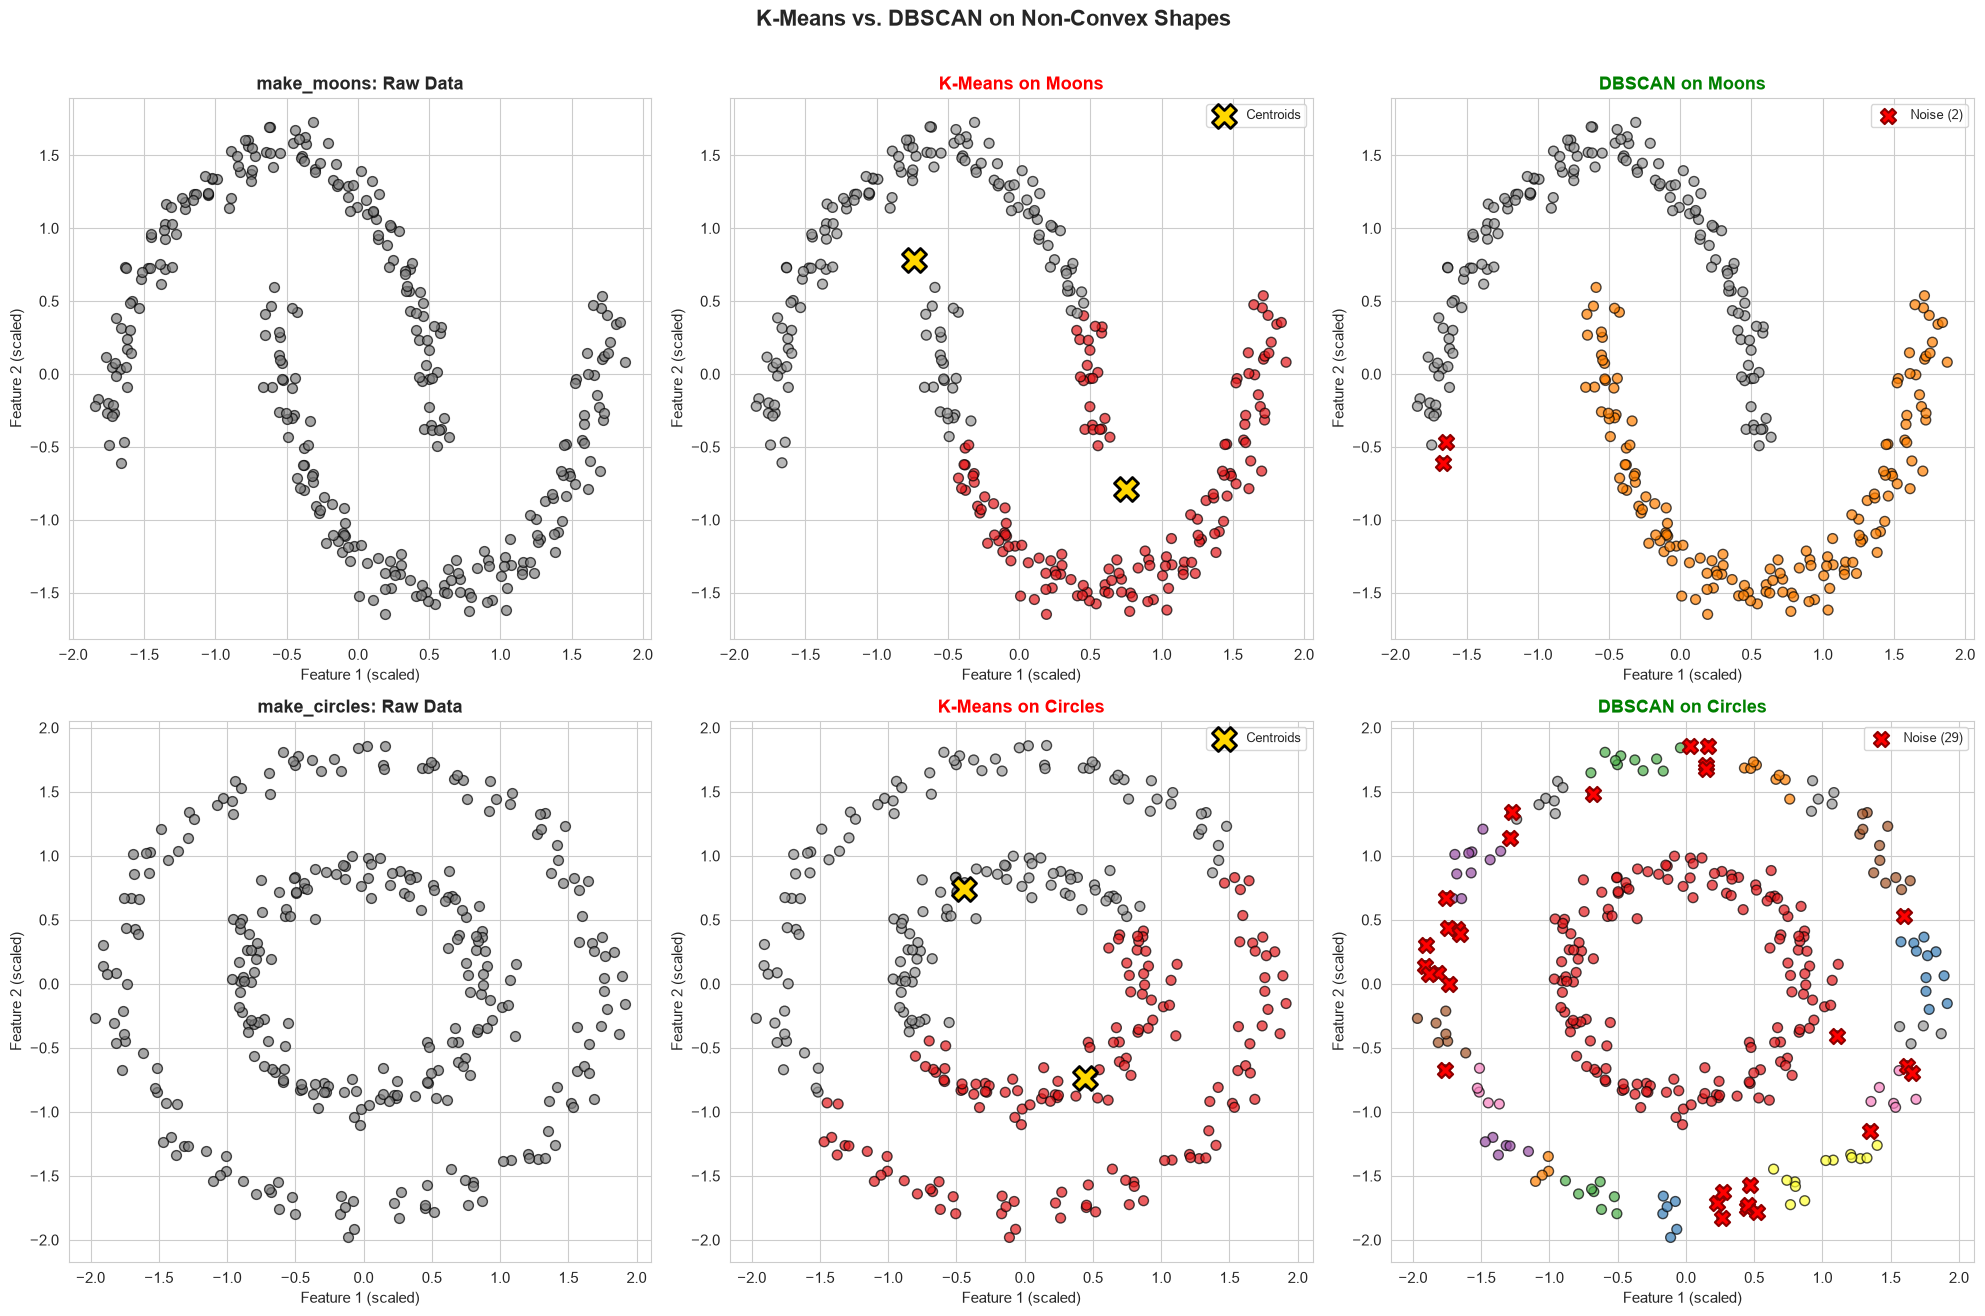


=== External Metrics on Synthetic Data ===
Dataset      | Algorithm  |      ARI |      NMI
------------------------------------------------
Moons        | K-Means    |   0.4697 |   0.3738
Moons        | DBSCAN     |   0.9868 |   0.9751
Circles      | K-Means    |  -0.0033 |   0.0000
Circles      | DBSCAN     |   0.5287 |   0.4910


In [17]:
# --- K-Means on Moons ---
kmeans_moons = KMeans(n_clusters=2, init='k-means++', n_init=10, 
                       random_state=RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

# --- DBSCAN on Moons ---
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_db_moons = dbscan_moons.fit_predict(X_moons)

# --- K-Means on Circles ---
kmeans_circles = KMeans(n_clusters=2, init='k-means++', n_init=10, 
                         random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# --- DBSCAN on Circles ---
dbscan_circles = DBSCAN(eps=0.2, min_samples=5)
labels_db_circles = dbscan_circles.fit_predict(X_circles)

# ==================== PLOTTING ====================
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

# ---- Row 1: MOONS ----
# Raw data
axes[0, 0].scatter(X_moons[:, 0], X_moons[:, 1], c='gray', s=50, 
                   edgecolors='k', alpha=0.7)
axes[0, 0].set_title('make_moons: Raw Data', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Feature 1 (scaled)')
axes[0, 0].set_ylabel('Feature 2 (scaled)')

# K-Means
axes[0, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km_moons, 
                    cmap='Set1', s=50, edgecolors='k', alpha=0.7)
# Show centroids
axes[0, 1].scatter(kmeans_moons.cluster_centers_[:, 0], 
                    kmeans_moons.cluster_centers_[:, 1],
                    marker='X', s=300, c='gold', edgecolors='black', 
                    linewidth=2, zorder=5, label='Centroids')
axes[0, 1].set_title('K-Means on Moons', fontsize=13, fontweight='bold', color='red')
axes[0, 1].set_xlabel('Feature 1 (scaled)')
axes[0, 1].set_ylabel('Feature 2 (scaled)')
axes[0, 1].legend(fontsize=9)

# DBSCAN
axes[0, 2].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db_moons, 
                    cmap='Set1', s=50, edgecolors='k', alpha=0.7)
n_noise_moons = (labels_db_moons == -1).sum()
if n_noise_moons > 0:
    axes[0, 2].scatter(X_moons[labels_db_moons == -1, 0], 
                        X_moons[labels_db_moons == -1, 1],
                        marker='X', s=120, c='red', edgecolors='darkred', 
                        linewidth=1.5, zorder=5, label=f'Noise ({n_noise_moons})')
    axes[0, 2].legend(fontsize=9)
axes[0, 2].set_title('DBSCAN on Moons', fontsize=13, fontweight='bold', color='green')
axes[0, 2].set_xlabel('Feature 1 (scaled)')
axes[0, 2].set_ylabel('Feature 2 (scaled)')

# ---- Row 2: CIRCLES ----
# Raw data
axes[1, 0].scatter(X_circles[:, 0], X_circles[:, 1], c='gray', s=50, 
                   edgecolors='k', alpha=0.7)
axes[1, 0].set_title('make_circles: Raw Data', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Feature 1 (scaled)')
axes[1, 0].set_ylabel('Feature 2 (scaled)')

# K-Means
axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_km_circles, 
                    cmap='Set1', s=50, edgecolors='k', alpha=0.7)
axes[1, 1].scatter(kmeans_circles.cluster_centers_[:, 0], 
                    kmeans_circles.cluster_centers_[:, 1],
                    marker='X', s=300, c='gold', edgecolors='black', 
                    linewidth=2, zorder=5, label='Centroids')
axes[1, 1].set_title('K-Means on Circles', fontsize=13, fontweight='bold', color='red')
axes[1, 1].set_xlabel('Feature 1 (scaled)')
axes[1, 1].set_ylabel('Feature 2 (scaled)')
axes[1, 1].legend(fontsize=9)

# DBSCAN
axes[1, 2].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_db_circles, 
                    cmap='Set1', s=50, edgecolors='k', alpha=0.7)
n_noise_circles = (labels_db_circles == -1).sum()
if n_noise_circles > 0:
    axes[1, 2].scatter(X_circles[labels_db_circles == -1, 0], 
                        X_circles[labels_db_circles == -1, 1],
                        marker='X', s=120, c='red', edgecolors='darkred', 
                        linewidth=1.5, zorder=5, label=f'Noise ({n_noise_circles})')
    axes[1, 2].legend(fontsize=9)
axes[1, 2].set_title('DBSCAN on Circles', fontsize=13, fontweight='bold', color='green')
axes[1, 2].set_xlabel('Feature 1 (scaled)')
axes[1, 2].set_ylabel('Feature 2 (scaled)')

plt.suptitle('K-Means vs. DBSCAN on Non-Convex Shapes', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Quantitative comparison
print("\n=== External Metrics on Synthetic Data ===")
print(f"{'Dataset':<12} | {'Algorithm':<10} | {'ARI':>8} | {'NMI':>8}")
print("-" * 48)
print(f"{'Moons':<12} | {'K-Means':<10} | {adjusted_rand_score(y_moons, labels_km_moons):>8.4f} | {normalized_mutual_info_score(y_moons, labels_km_moons):>8.4f}")
print(f"{'Moons':<12} | {'DBSCAN':<10} | {adjusted_rand_score(y_moons, labels_db_moons):>8.4f} | {normalized_mutual_info_score(y_moons, labels_db_moons):>8.4f}")
print(f"{'Circles':<12} | {'K-Means':<10} | {adjusted_rand_score(y_circles, labels_km_circles):>8.4f} | {normalized_mutual_info_score(y_circles, labels_km_circles):>8.4f}")
print(f"{'Circles':<12} | {'DBSCAN':<10} | {adjusted_rand_score(y_circles, labels_db_circles):>8.4f} | {normalized_mutual_info_score(y_circles, labels_db_circles):>8.4f}")

## Overall comparison

The final table provides a final comparison for the three clustering algorithms.

In [18]:
# Summary
summary_data = {
    'Algorithm': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Clusters Found': [K_CHOSEN, HIER_K, n_clusters_dbscan],
    'Noise Points': [0, 0, dbscan_noise],
    'Silhouette': [kmeans_sil, hier_sil, dbscan_sil],
    'Davies-Bouldin': [kmeans_db, hier_db, dbscan_db],
    'ARI': [kmeans_ari, hier_ari, dbscan_ari],
    'NMI': [kmeans_nmi, hier_nmi, dbscan_nmi],
    'Fit Time (s)': [kmeans_time, hier_time, dbscan_time]
}

summary_df = pd.DataFrame(summary_data)

# Format for display
display_df = summary_df.copy()
display_df['Silhouette'] = display_df['Silhouette'].round(4)
display_df['Davies-Bouldin'] = display_df['Davies-Bouldin'].round(4)
display_df['ARI'] = display_df['ARI'].round(4)
display_df['NMI'] = display_df['NMI'].round(4)
display_df['Fit Time (s)'] = display_df['Fit Time (s)'].apply(lambda x: f"{x:.6f}")

print("=" * 100)
print("  FINAL COMPARISON TABLE: Iris Dataset")
print("=" * 100)
print(display_df.to_string(index=False))
print("=" * 100)

# Highlight best values
print("\nBest Values:")
print(f"   Best Silhouette:       {summary_df.loc[summary_df['Silhouette'].idxmax(), 'Algorithm']} ({summary_df['Silhouette'].max():.4f})")
print(f"   Best Davies-Bouldin:   {summary_df.loc[summary_df['Davies-Bouldin'].idxmin(), 'Algorithm']} ({summary_df['Davies-Bouldin'].min():.4f})")
print(f"   Best ARI:              {summary_df.loc[summary_df['ARI'].idxmax(), 'Algorithm']} ({summary_df['ARI'].max():.4f})")
print(f"   Best NMI:              {summary_df.loc[summary_df['NMI'].idxmax(), 'Algorithm']} ({summary_df['NMI'].max():.4f})")
print(f"   Fastest Fit Time:      {summary_df.loc[summary_df['Fit Time (s)'].idxmin(), 'Algorithm']} ({summary_df['Fit Time (s)'].min():.6f}s)")

  FINAL COMPARISON TABLE: Iris Dataset
          Algorithm  Clusters Found  Noise Points  Silhouette  Davies-Bouldin    ARI    NMI Fit Time (s)
            K-Means               3             0      0.4599          0.8336 0.6201 0.6595     0.005996
Hierarchical (Ward)               3             0      0.4467          0.8035 0.6153 0.6755     0.001121
             DBSCAN               2             4      0.5979          0.5688 0.5518 0.6900     0.001752

Best Values:
   Best Silhouette:       DBSCAN (0.5979)
   Best Davies-Bouldin:   DBSCAN (0.5688)
   Best ARI:              K-Means (0.6201)
   Best NMI:              DBSCAN (0.6900)
   Fastest Fit Time:      Hierarchical (Ward) (0.001121s)


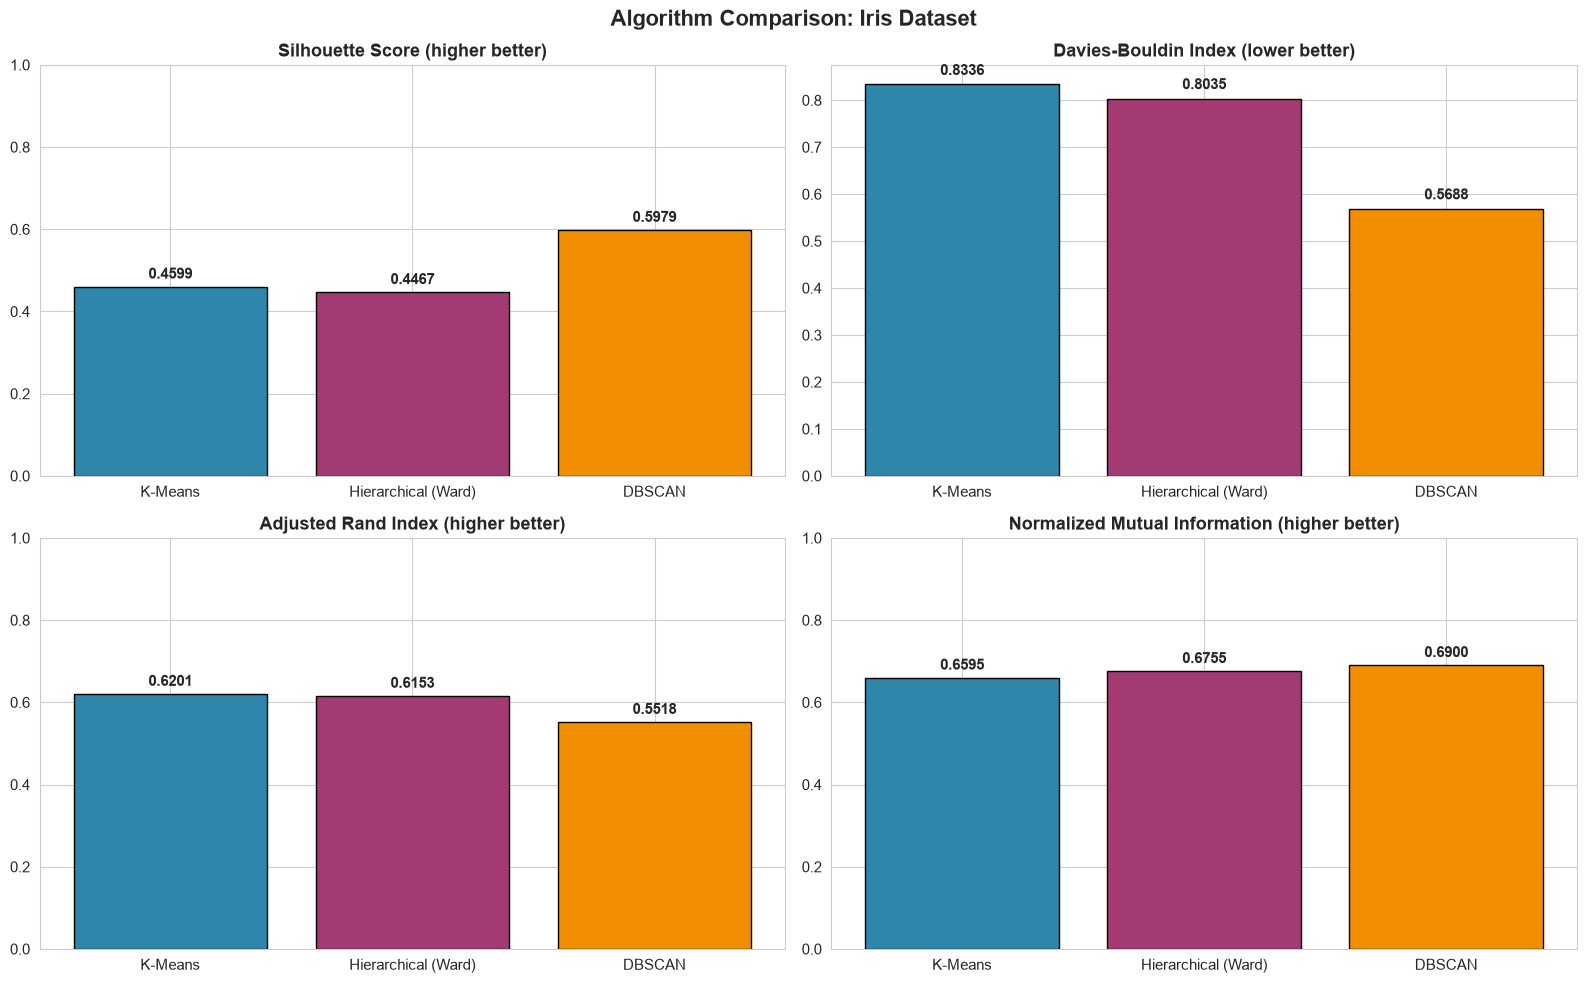

In [19]:
# visual metric comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

algorithms = summary_df['Algorithm']
colors = ['#2E86AB', '#A23B72', '#F18F01']

# Silhouette
axes[0, 0].bar(algorithms, summary_df['Silhouette'], color=colors, edgecolor='black')
axes[0, 0].set_title('Silhouette Score (higher better)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(summary_df['Silhouette']):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Davies-Bouldin
axes[0, 1].bar(algorithms, summary_df['Davies-Bouldin'], color=colors, edgecolor='black')
axes[0, 1].set_title('Davies-Bouldin Index (lower better)', fontsize=13, fontweight='bold')
for i, v in enumerate(summary_df['Davies-Bouldin']):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# ARI
axes[1, 0].bar(algorithms, summary_df['ARI'], color=colors, edgecolor='black')
axes[1, 0].set_title('Adjusted Rand Index (higher better)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylim(0, 1)
for i, v in enumerate(summary_df['ARI']):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# NMI
axes[1, 1].bar(algorithms, summary_df['NMI'], color=colors, edgecolor='black')
axes[1, 1].set_title('Normalized Mutual Information (higher better)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylim(0, 1)
for i, v in enumerate(summary_df['NMI']):
    axes[1, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Algorithm Comparison: Iris Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

### k-Means
Best suited to problems where the desired groups are compact and reasonably convex, and where a sensible value of $k$ is available. It is simple and typically fast, but its assumptions can be a poor match for irregular shapes.

### Agglomerative hierarchical clustering
Useful when the **hierarchy of relationships** between observations is interesting or when a dendrogram can help explore possible clusterings. Ward linkage is a strong choice for compact Euclidean clusters, but other linkages may tell a different story.

### DBSCAN
Useful when clusters are defined by **density** and when noise/outliers are meaningful. It can discover non-convex structures and does not require the number of clusters in advance. Its main challenge is selecting a density scale that works across the dataset.

## Conclusion

The central lesson of this experiment is that clustering quality cannot be separated from the assumptions of the algorithm and the geometry of the data. A robust workflow therefore combines data preprocessing, parameter diagnostics, visualization, multiple evaluation metrics and interpretation of the underlying assumptions, rather than relying on a single score.